# Perplexity And Spell-Checker Evaluation

This notebook follows `perplexity_evaluation.md`:

- N-gram: character-pattern / non-word analysis using character n-gram probability and candidate overlap.
- RNN: optional contextual analysis using sentence perplexity when TensorFlow is available.
- Hybrid: short synthesis of what each model catches and misses.


In [20]:
from pathlib import Path
import csv
import math
import sys

ROOT = Path.cwd()
if not (ROOT / 'app.py').exists():
    ROOT = ROOT.parent.parent

sys.path.insert(0, str(ROOT / 'model' / 'n_gram'))
sys.path.insert(0, str(ROOT / 'model' / 'RNN'))

from ngram_spell_checker import NGramSpellChecker, generate_ngrams, tokenize_words

RUN_RNN = False  # Set True after TensorFlow is installed in this notebook kernel.
TEST_PATH = ROOT / 'model' / 'specil_test.csv'
MAX_ROWS = 1000
print(ROOT)


e:\8. Mata Kuliah\Semester 6\IoT Kecerdasan Artifisial\FinalProject_MorseNLP


In [21]:
def load_pairs(limit=MAX_ROWS):
    rows = []
    with TEST_PATH.open(encoding='utf-8', newline='') as f:
        for row in csv.DictReader(f):
            rows.append((row['wrong_text'], row['correct_text'], row.get('error_type', '')))
            if len(rows) >= limit:
                break
    return rows

pairs = load_pairs()
sentences = [correct for _, correct, _ in pairs]
len(pairs), pairs[:2]


(1000,
 [('diskusikan gambar sampul di atas dengan menawab pertanyaan-pertanyaan ini .',
   'diskusikan gambar sampul di atas dengan menjawab pertanyaan-pertanyaan ini .',
   'Deletion Error'),
  ('bola boni bir .', 'bola boni biru .', 'Deletion Error')])

## N-gram Evaluation: Pattern And Non-Word Analysis

The N-gram model is a character N-gram spell checker. Here, perplexity is calculated over learned character trigrams from the artifact. Higher token perplexity means the word contains less familiar character patterns.


In [22]:
ngram = NGramSpellChecker.load(ROOT / 'model' / 'n_gram' / 'ngram_spell_checker.json.gz')


def char_ngram_perplexity(model, words, n='3'):
    table = model.ngram_frequency[n]
    total = sum(table.values())
    vocab_size = max(len(table), 1)
    nll = 0.0
    count = 0
    for word in words:
        for gram in generate_ngrams(word, [int(n)], model.config['use_boundary_markers'])[n]:
            probability = (table.get(gram, 0) + 1) / (total + vocab_size)
            nll -= math.log(probability)
            count += 1
    return math.exp(nll / max(count, 1))


def sentence_ngram_ppl(text):
    return char_ngram_perplexity(ngram, tokenize_words(text), n='3')

ngram_ppl = char_ngram_perplexity(ngram, tokenize_words(' '.join(sentences)), n='3')
ngram_ppl


947.3489735588531

## Candidate Generation With Jaccard Overlap

For likely non-word errors, the model generates candidates from the character N-gram inverted index and ranks them with overlap, edit distance, frequency, and length similarity. The table below shows the top candidates for sample typo tokens.


In [23]:
def candidate_report(word, limit=5):
    rows = []
    for candidate in ngram.candidates(word)[:limit]:
        score, features = ngram.score(word, candidate)
        rows.append({
            'word': word,
            'candidate': candidate,
            'score': round(score, 4),
            'jaccard': round(features['jaccard_similarity'], 4),
            'edit_distance': features['edit_distance'],
            'frequency': features['word_frequency'],
        })
    return rows

sample_typos = ['meken', 'sekolh', 'Indonesai', 'makn']
ngram_candidate_analysis = [row for word in sample_typos for row in candidate_report(word)]
ngram_candidate_analysis


[{'word': 'meken',
  'candidate': 'menekan',
  'score': 0.5018,
  'jaccard': 0.4444,
  'edit_distance': 3,
  'frequency': 108},
 {'word': 'meken',
  'candidate': 'mekanik',
  'score': 0.4879,
  'jaccard': 0.3793,
  'edit_distance': 3,
  'frequency': 91},
 {'word': 'meken',
  'candidate': 'mekanis',
  'score': 0.4191,
  'jaccard': 0.3667,
  'edit_distance': 3,
  'frequency': 9},
 {'word': 'meken',
  'candidate': 'mekhong',
  'score': 0.4719,
  'jaccard': 0.3667,
  'edit_distance': 3,
  'frequency': 56},
 {'word': 'meken',
  'candidate': 'mekong',
  'score': 0.5371,
  'jaccard': 0.4074,
  'edit_distance': 2,
  'frequency': 80},
 {'word': 'sekolh',
  'candidate': 'sekolah',
  'score': 0.7586,
  'jaccard': 0.6667,
  'edit_distance': 1,
  'frequency': 3734},
 {'word': 'sekolh',
  'candidate': 'sekolahan',
  'score': 0.4691,
  'jaccard': 0.5152,
  'edit_distance': 3,
  'frequency': 11},
 {'word': 'sekolh',
  'candidate': 'sekolahku',
  'score': 0.4926,
  'jaccard': 0.5152,
  'edit_distance':

## N-gram Blind Spots: Real-Word Errors

A valid Indonesian word used in the wrong context can have normal character patterns, so the N-gram spell checker may not flag it. The next cell finds SPECIL rows where the wrong token already exists in the N-gram vocabulary.


In [24]:
def real_word_examples(limit=8):
    examples = []
    for wrong, correct, error_type in pairs:
        wrong_tokens = tokenize_words(wrong)
        correct_tokens = tokenize_words(correct)
        if len(wrong_tokens) != len(correct_tokens):
            continue
        for bad, good in zip(wrong_tokens, correct_tokens):
            if bad != good and bad in ngram.vocabulary:
                examples.append({
                    'wrong_sentence': wrong,
                    'correct_sentence': correct,
                    'real_word': bad,
                    'target': good,
                    'error_type': error_type,
                    'wrong_ppl': round(sentence_ngram_ppl(wrong), 2),
                    'correct_ppl': round(sentence_ngram_ppl(correct), 2),
                })
                break
        if len(examples) >= limit:
            break
    return examples

ngram_blind_spots = real_word_examples()
ngram_blind_spots


[{'wrong_sentence': 'pada siang har ?',
  'correct_sentence': 'pada siang hari ?',
  'real_word': 'har',
  'target': 'hari',
  'error_type': 'Deletion Error',
  'wrong_ppl': 676.0,
  'correct_ppl': 679.93},
 {'wrong_sentence': 'pada malam har ?',
  'correct_sentence': 'pada malam hari ?',
  'real_word': 'har',
  'target': 'hari',
  'error_type': 'Deletion Error',
  'wrong_ppl': 887.14,
  'correct_ppl': 873.83},
 {'wrong_sentence': 'saya bisa membaca ba , bi , bu , b , bo .',
  'correct_sentence': 'saya bisa membaca ba , bi , bu , be , bo .',
  'real_word': 'b',
  'target': 'be',
  'error_type': 'Deletion Error',
  'wrong_ppl': 1592.64,
  'correct_ppl': 1352.46},
 {'wrong_sentence': 'ikuti guru membaca kalimat-kalimat di bawah ni .',
  'correct_sentence': 'ikuti guru membaca kalimat-kalimat di bawah ini .',
  'real_word': 'ni',
  'target': 'ini',
  'error_type': 'Deletion Error',
  'wrong_ppl': 1390.25,
  'correct_ppl': 1355.56},
 {'wrong_sentence': 'apa yang terjadi ada kuman itu ?',
 

## Sequential Network / Perplexity Evaluation

The RNN section is optional because it needs TensorFlow in the active notebook kernel. When enabled, it compares wrong and corrected sentences by perplexity. Lower perplexity means the sentence is more predictable to the sequential model.


In [25]:
rnn_ppl = None
rnn_context_analysis = []

if RUN_RNN:
    try:
        from specil_rnn_spellchecker import SpecilRnnSpellChecker
        rnn = SpecilRnnSpellChecker.load()

        def rnn_sentence_ppl(text):
            return math.exp(-rnn.score(text))

        rnn_ppl = sum(rnn_sentence_ppl(s) for s in sentences[:100]) / max(len(sentences[:100]), 1)
        for wrong, correct, error_type in pairs[:20]:
            rnn_context_analysis.append({
                'wrong_sentence': wrong,
                'correct_sentence': correct,
                'wrong_ppl': round(rnn_sentence_ppl(wrong), 2),
                'correct_ppl': round(rnn_sentence_ppl(correct), 2),
                'error_type': error_type,
            })
    except ModuleNotFoundError as e:
        print('RNN skipped:', e)
else:
    print('RNN skipped: set RUN_RNN = True to run TensorFlow perplexity.')

rnn_ppl, rnn_context_analysis[:5]


RNN skipped: set RUN_RNN = True to run TensorFlow perplexity.


(None, [])

## Hybrid Synthesis

Use the character N-gram model first for fast non-word detection and candidate correction. Use the sequential model/perplexity pass for context-sensitive real-word errors, where character patterns look valid but the sentence becomes less predictable.


In [26]:
perplexity_results = {
    'ngram_char_trigram_perplexity': ngram_ppl,
    'rnn_sentence_perplexity': rnn_ppl,
    'ngram_strength': 'fast non-word detection from rare character patterns and candidate overlap',
    'ngram_blind_spot': 'real-word/context errors because grammar and sentence context are not modeled',
    'rnn_strength': 'contextual uncertainty through sentence perplexity when TensorFlow model is enabled',
}
perplexity_results


{'ngram_char_trigram_perplexity': 947.3489735588531,
 'rnn_sentence_perplexity': None,
 'ngram_strength': 'fast non-word detection from rare character patterns and candidate overlap',
 'ngram_blind_spot': 'real-word/context errors because grammar and sentence context are not modeled',
 'rnn_strength': 'contextual uncertainty through sentence perplexity when TensorFlow model is enabled'}

## Matplotlib Visualization

Install matplotlib with `.env\python.exe -m pip install matplotlib` before running this cell.


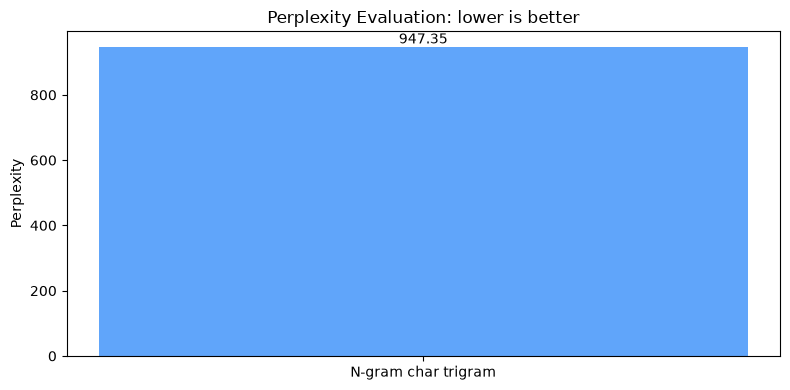

In [27]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as e:
    raise ModuleNotFoundError('matplotlib is required. Run: .env\\python.exe -m pip install matplotlib') from e

labels = ['N-gram char trigram']
values = [ngram_ppl]
if rnn_ppl is not None:
    labels.append('RNN sentence')
    values.append(rnn_ppl)

plt.figure(figsize=(8, 4))
plt.bar(labels, values, color=['#60a5fa', '#f87171'][:len(labels)])
plt.title('Perplexity Evaluation: lower is better')
plt.ylabel('Perplexity')
for i, value in enumerate(values):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()
